
ШАГ 1. Загрузка данных
Raw shape: (30001, 25)
    ID        X1   X2   X3   X4    X5   X6   X7   X8   X9  X10  X11      X12      X13      X14      X15      X16      X17     X18     X19     X20     X21     X22     X23    Y
0  NaN       NaN  NaN  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN      NaN      NaN      NaN      NaN      NaN      NaN     NaN     NaN     NaN     NaN     NaN     NaN  NaN
1  1.0   20000.0  2.0  2.0  1.0  24.0  2.0  2.0 -1.0 -1.0 -2.0 -2.0   3913.0   3102.0    689.0      0.0      0.0      0.0     0.0   689.0     0.0     0.0     0.0     0.0  1.0
2  2.0  120000.0  2.0  2.0  2.0  26.0 -1.0  2.0  0.0  0.0  0.0  2.0   2682.0   1725.0   2682.0   3272.0   3455.0   3261.0     0.0  1000.0  1000.0  1000.0     0.0  2000.0  1.0
3  3.0   90000.0  2.0  2.0  2.0  34.0  0.0  0.0  0.0  0.0  0.0  0.0  29239.0  14027.0  13559.0  14331.0  14948.0  15549.0  1518.0  1500.0  1000.0  1000.0  1000.0  5000.0  0.0
4  4.0   50000.0  2.0  2.0  1.0  37.0  0.0  0.0  0.0  0.0  0.0  0.0  46990.0  

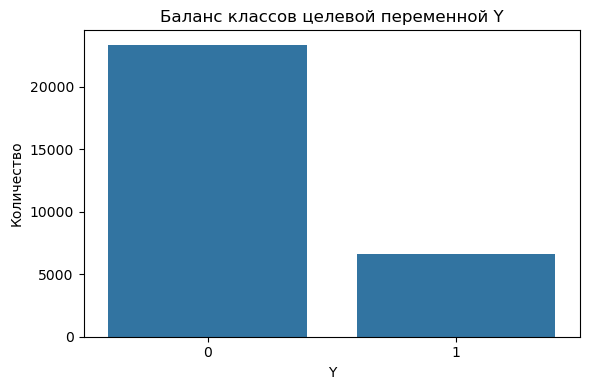


ШАГ 4. Корреляционная матрица


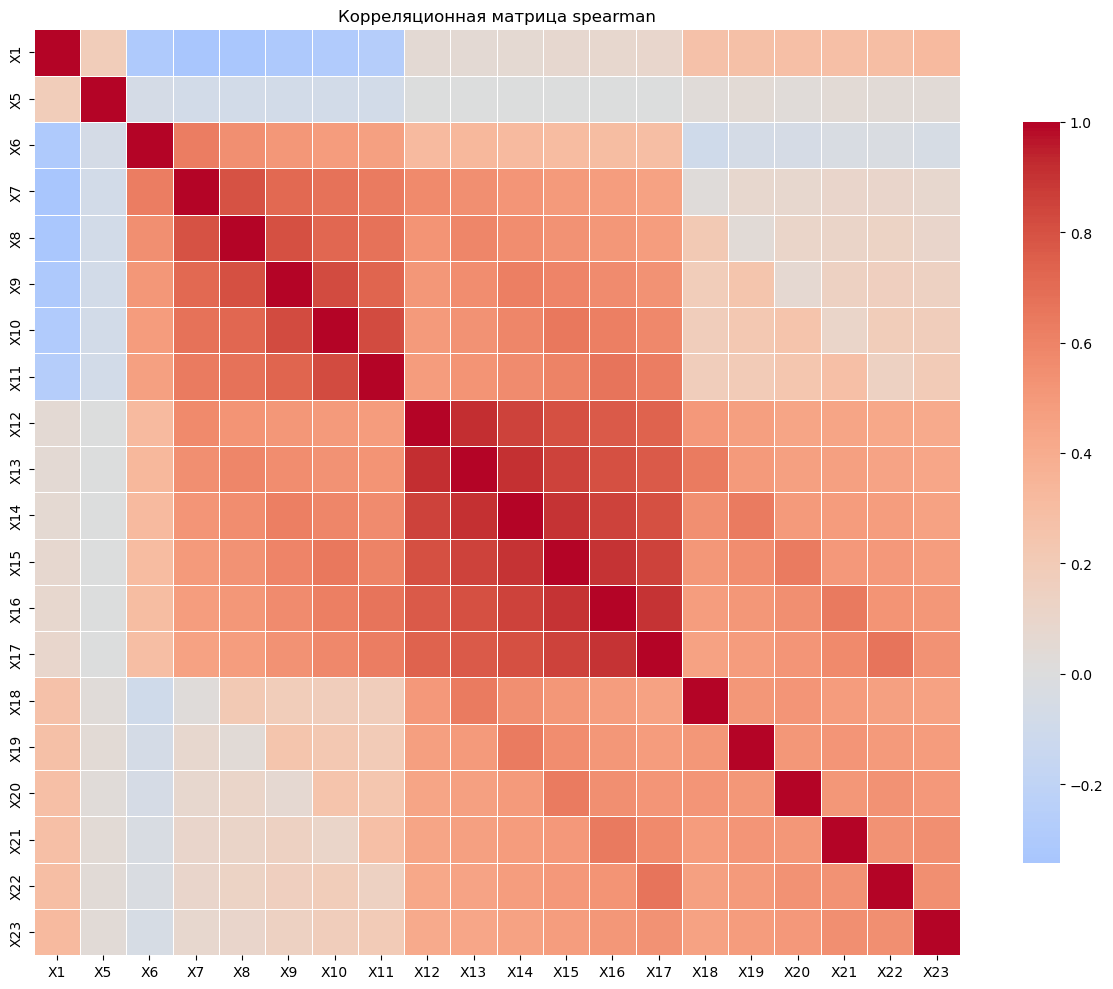

Количество пар с |corr| > 0.9: 5
feature_1 feature_2  abs_corr
      X12       X13  0.911133
      X13       X14  0.907740
      X14       X15  0.903640
      X15       X16  0.902787
      X16       X17  0.902097

ШАГ 5. Gain Ratio до удаления коррелирующих признаков
feature  gain_ratio  info_gain  split_info
     X6    0.055055   0.075831    1.377372
     X7    0.040611   0.048896    1.204012
     X8    0.030700   0.037016    1.205736
     X9    0.027489   0.032314    1.175530
    X11    0.021862   0.025743    1.177521
     X1    0.006600   0.015067    2.283008
    X18    0.006448   0.013925    2.159548
    X19    0.005689   0.012301    2.162312
    X20    0.004885   0.010568    2.163457
    X21    0.003888   0.007679    1.975350
    X23    0.003845   0.007573    1.969363
    X10    0.003685   0.003205    0.869841
    X22    0.003462   0.006824    1.971272
     X3    0.002732   0.002962    1.084310
     X2    0.001181   0.000793    0.671469


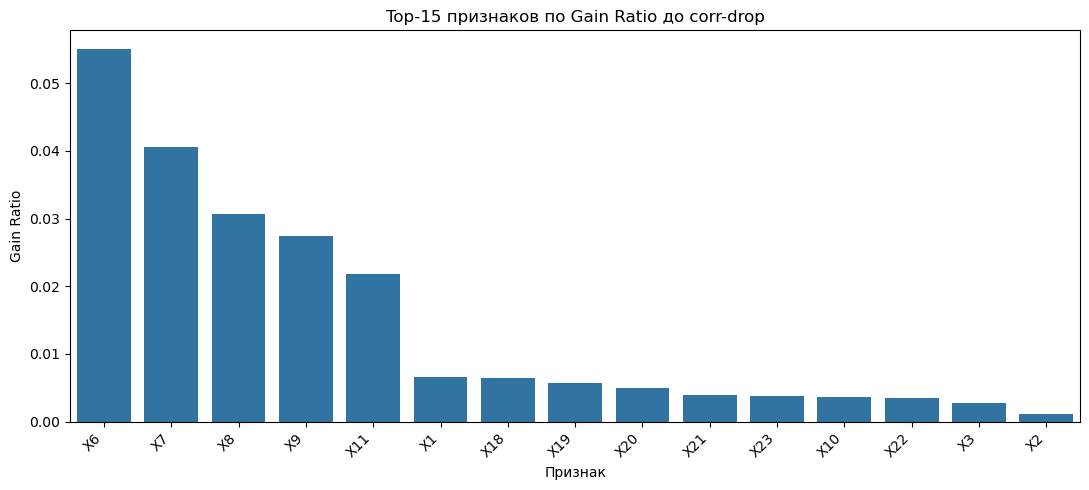


ШАГ 6. Удаление сильно коррелирующих признаков
Удаляем признаки:
['X12', 'X14', 'X15', 'X16']

ШАГ 7. Проверка корреляций после удаления
Пар с |corr| > 0.9 после удаления: 0


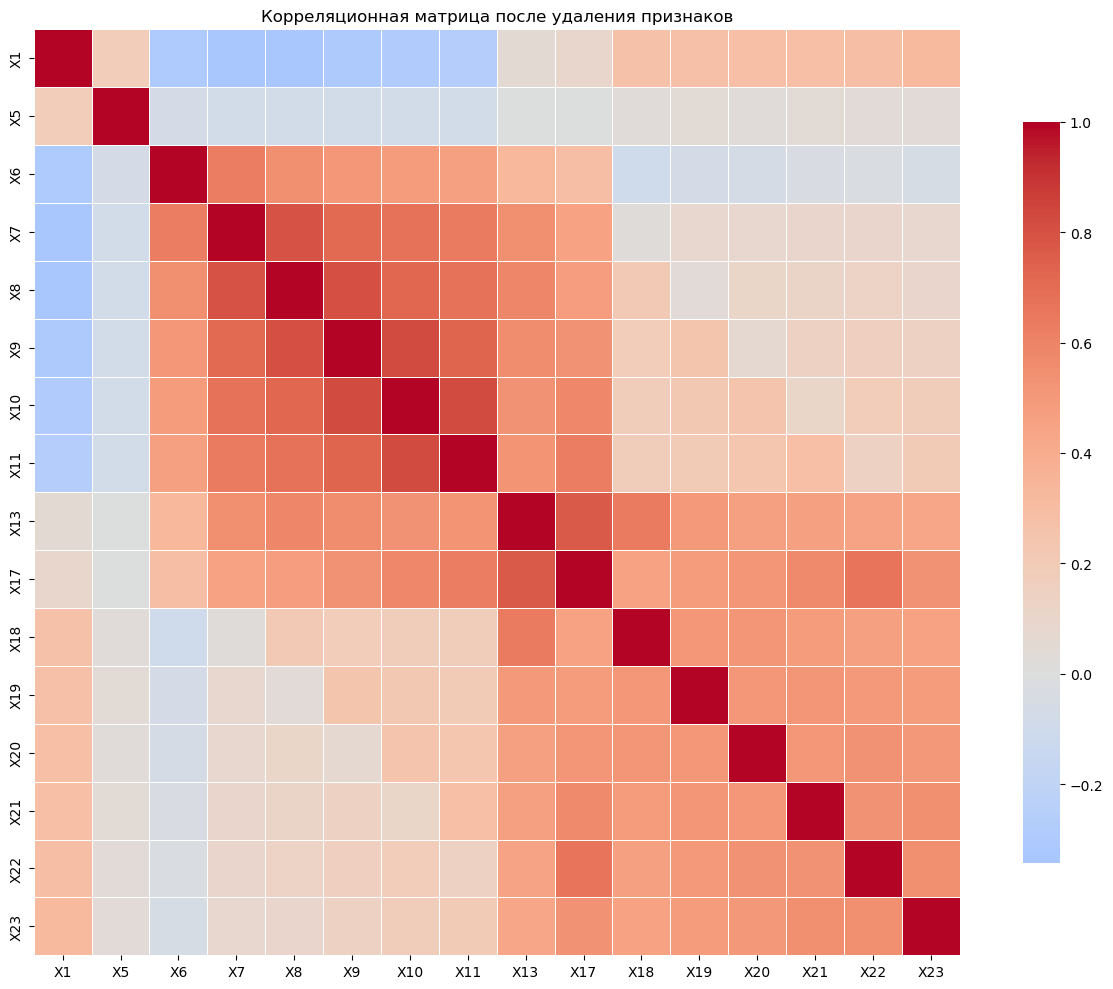


ШАГ 8. Gain Ratio после corr-drop
feature  gain_ratio  info_gain  split_info
     X6    0.055055   0.075831    1.377372
     X7    0.040611   0.048896    1.204012
     X8    0.030700   0.037016    1.205736
     X9    0.027489   0.032314    1.175530
    X11    0.021862   0.025743    1.177521
     X1    0.006600   0.015067    2.283008
    X18    0.006448   0.013925    2.159548
    X19    0.005689   0.012301    2.162312
    X20    0.004885   0.010568    2.163457
    X21    0.003888   0.007679    1.975350
    X23    0.003845   0.007573    1.969363
    X10    0.003685   0.003205    0.869841
    X22    0.003462   0.006824    1.971272
     X3    0.002732   0.002962    1.084310
     X2    0.001181   0.000793    0.671469


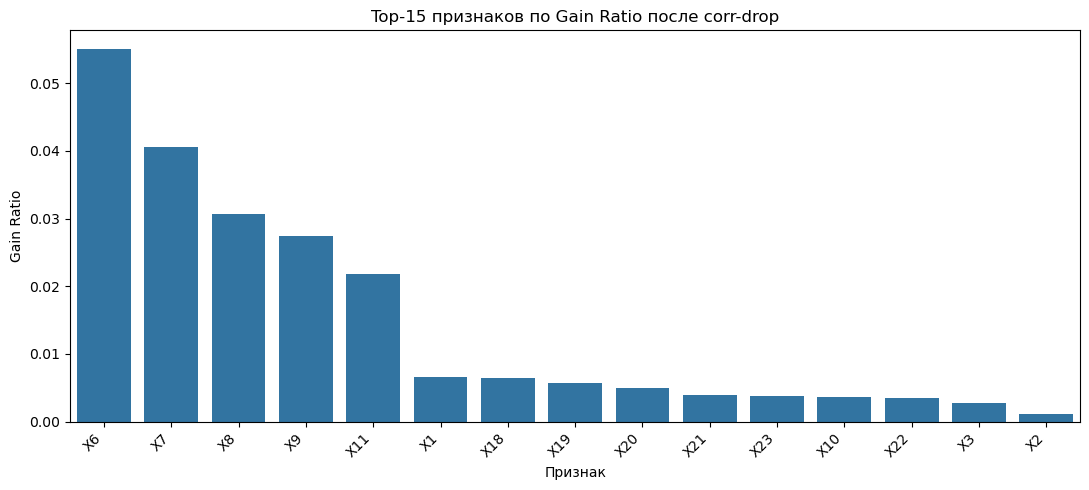


ШАГ 9. Выбор итоговых признаков
Выбранные top-10 признаки:
['X6', 'X7', 'X8', 'X9', 'X11', 'X1', 'X18', 'X19', 'X20', 'X21']

Первые строки итогового датасета:
    X6   X7   X8   X9  X11        X1     X18      X19      X20     X21  Y
0  2.0  2.0 -1.0 -1.0 -2.0   20000.0     0.0    689.0      0.0     0.0  1
1 -1.0  2.0  0.0  0.0  2.0  120000.0     0.0   1000.0   1000.0  1000.0  1
2  0.0  0.0  0.0  0.0  0.0   90000.0  1518.0   1500.0   1000.0  1000.0  0
3  0.0  0.0  0.0  0.0  0.0   50000.0  2000.0   2019.0   1200.0  1100.0  0
4 -1.0  0.0 -1.0  0.0  0.0   50000.0  2000.0  36681.0  10000.0  9000.0  0

ШАГ 10. Обучение C4.5

ОЦЕНКА C45Classifier
Accuracy: 0.4764

Confusion matrix:
[[2469 3372]
 [ 555 1104]]

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.42      0.56      5841
           1       0.25      0.67      0.36      1659

    accuracy                           0.48      7500
   macro avg       0.53      0.54      0.46  

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from C45 import C45Classifier


PATH = "credit_default.xls"

CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.90
TOP_K = 10
N_BINS = 10
RANDOM_STATE = 42

CATEGORICAL_COLS = ["X2", "X3", "X4"]
TARGET_COL = "Y"


def print_section(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Приведение датасета к единому виду:
    ID, X1...X23, Y
    """
    df = df.copy()
    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]

    rename_map = {
        "Unnamed: 0": "ID",
        "LIMIT_BAL": "X1",
        "SEX": "X2",
        "EDUCATION": "X3",
        "MARRIAGE": "X4",
        "AGE": "X5",
        "PAY_0": "X6",
        "PAY_2": "X7",
        "PAY_3": "X8",
        "PAY_4": "X9",
        "PAY_5": "X10",
        "PAY_6": "X11",
        "BILL_AMT1": "X12",
        "BILL_AMT2": "X13",
        "BILL_AMT3": "X14",
        "BILL_AMT4": "X15",
        "BILL_AMT5": "X16",
        "BILL_AMT6": "X17",
        "PAY_AMT1": "X18",
        "PAY_AMT2": "X19",
        "PAY_AMT3": "X20",
        "PAY_AMT4": "X21",
        "PAY_AMT5": "X22",
        "PAY_AMT6": "X23",
        "default payment next month": "Y",
    }

    df = df.rename(columns=rename_map)

    standard_cols = ["ID"] + [f"X{i}" for i in range(1, 24)] + ["Y"]

    if len(df.columns) >= 25 and not all(c in df.columns for c in ["X1", "X23", "Y"]):
        df = df.rename(columns=dict(zip(df.columns[:25], standard_cols)))

    keep_cols = [c for c in standard_cols if c in df.columns]
    return df[keep_cols]


def load_dataset(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    df = normalize_columns(df)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def clean_dataset(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    report = {}
    df = df.copy()

    report["shape_before"] = df.shape
    report["nan_before"] = int(df.isna().sum().sum())
    report["full_duplicates_before"] = int(df.duplicated().sum())

    if "ID" in df.columns:
        report["id_duplicates_before"] = int(df["ID"].duplicated().sum())
        df = df.drop_duplicates(subset=["ID"], keep="first")

    df = df.drop_duplicates()

    before = len(df)
    df = df.dropna(subset=[TARGET_COL]).copy()
    report["dropped_missing_target"] = before - len(df)

    df[TARGET_COL] = df[TARGET_COL].astype(int)

    x_cols = [f"X{i}" for i in range(1, 24)]

    cat_cols = [c for c in CATEGORICAL_COLS if c in df.columns]
    num_cols = [c for c in x_cols if c in df.columns and c not in cat_cols]

    if cat_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

    if num_cols:
        num_imputer = SimpleImputer(strategy="median")
        df[num_cols] = num_imputer.fit_transform(df[num_cols])

    domain_report = restore_domains(df)
    report.update(domain_report)

    report["nan_after"] = int(df.isna().sum().sum())
    report["shape_after"] = df.shape

    return df.reset_index(drop=True), report


def restore_domains(df: pd.DataFrame) -> dict:
    """
    Исправление значений которые невозможны по смыслу датасета.
    """
    report = {}

    if "X2" in df.columns:
        bad = ~df["X2"].isin([1, 2])
        report["bad_X2_fixed"] = int(bad.sum())
        if bad.any():
            df.loc[bad, "X2"] = df.loc[~bad, "X2"].mode()[0]

    if "X3" in df.columns:
        bad = ~df["X3"].isin([1, 2, 3, 4])
        report["bad_X3_to_4"] = int(bad.sum())
        if bad.any():
            df.loc[bad, "X3"] = 4

    if "X4" in df.columns:
        bad = ~df["X4"].isin([1, 2, 3])
        report["bad_X4_to_3"] = int(bad.sum())
        if bad.any():
            df.loc[bad, "X4"] = 3

    if "X5" in df.columns:
        bad = (df["X5"] <= 0) | (df["X5"].isna())
        report["bad_X5_fixed"] = int(bad.sum())
        if bad.any():
            df.loc[bad, "X5"] = df.loc[~bad, "X5"].median()

    return report


def plot_target_balance(df: pd.DataFrame):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=TARGET_COL)
    plt.title("Баланс классов целевой переменной Y")
    plt.xlabel("Y")
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.show()


def plot_corr_heatmap(corr: pd.DataFrame, title: str):
    plt.figure(figsize=(13, 10))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.4,
        cbar_kws={"shrink": 0.8}
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


def get_high_corr_pairs(corr_abs: pd.DataFrame, threshold: float) -> pd.DataFrame:
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
        .sort_values("abs_corr", ascending=False)
    )

    return pairs[pairs["abs_corr"] > threshold].reset_index(drop=True)


def discretize_for_gain_ratio(X: pd.DataFrame) -> pd.DataFrame:
    """
    Дискретизация признаков для GR:
    """
    X_disc = pd.DataFrame(index=X.index)

    for col in X.columns:
        if col in CATEGORICAL_COLS:
            X_disc[col] = X[col].astype(int)
        else:
            unique_count = X[col].nunique()

            if unique_count <= 1:
                X_disc[col] = 0
            else:
                bins = min(N_BINS, unique_count)

                discretizer = KBinsDiscretizer(
                    n_bins=bins,
                    encode="ordinal",
                    strategy="quantile"
                )

                X_disc[col] = discretizer.fit_transform(X[[col]]).ravel().astype(int)

    return X_disc


def gain_ratio_library(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """
    Библиотечный расчет Gain Ratio:
    """
    X_disc = discretize_for_gain_ratio(X)

    info_gain = mutual_info_classif(
        X_disc,
        y,
        discrete_features=True,
        random_state=RANDOM_STATE
    )

    rows = []

    for idx, col in enumerate(X_disc.columns):
        counts = X_disc[col].value_counts().values
        probs = counts / counts.sum()

        split_info = entropy(probs)
        gain_ratio = info_gain[idx] / split_info if split_info > 1e-12 else 0.0

        rows.append({
            "feature": col,
            "gain_ratio": gain_ratio,
            "info_gain": info_gain[idx],
            "split_info": split_info
        })

    return (
        pd.DataFrame(rows)
        .sort_values("gain_ratio", ascending=False)
        .reset_index(drop=True)
    )


def plot_gain_ratio(scores: pd.DataFrame, top_n: int = 15, title: str = "Top features by Gain Ratio"):
    top = scores.head(top_n)

    plt.figure(figsize=(11, 5))
    sns.barplot(data=top, x="feature", y="gain_ratio")
    plt.title(title)
    plt.xlabel("Признак")
    plt.ylabel("Gain Ratio")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def drop_correlated_features(X: pd.DataFrame, corr_pairs: pd.DataFrame, scores: pd.DataFrame) -> list:
    """
     из каждой сильно коррелирующей пары удаляем тот признак у которого Gr меньше.
    """
    gr_map = dict(zip(scores["feature"], scores["gain_ratio"]))
    to_drop = set()

    for _, row in corr_pairs.iterrows():
        a = row["feature_1"]
        b = row["feature_2"]

        if a in to_drop or b in to_drop:
            continue

        if gr_map.get(a, 0) >= gr_map.get(b, 0):
            to_drop.add(b)
        else:
            to_drop.add(a)

    return sorted(to_drop)


def train_c45_model(X: pd.DataFrame, y: pd.Series):
    """
    Обучение  C4.5 через
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y
    )

    model = C45Classifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print_section("ОЦЕНКА C45Classifier")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    return model


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


print_section("ШАГ 1. Загрузка данных")
df_raw = load_dataset(PATH)
print("Raw shape:", df_raw.shape)
print(df_raw.head())


print_section("ШАГ 2. Очистка и восстановление данных")
df, report = clean_dataset(df_raw)
print(report)
print("Clean shape:", df.shape)
print(df.head())


x_cols = [f"X{i}" for i in range(1, 24)]
X = df[x_cols].copy()
y = df[TARGET_COL].copy()


print_section("ШАГ 3. Баланс классов")
print(y.value_counts().sort_index())
plot_target_balance(df)


print_section("ШАГ 4. Корреляционная матрица")
X_for_corr = X.drop(columns=[c for c in CATEGORICAL_COLS if c in X.columns])

corr = X_for_corr.corr(method=CORR_METHOD)
corr_abs = corr.abs()

plot_corr_heatmap(corr, f"Корреляционная матрица {CORR_METHOD}")

corr_pairs = get_high_corr_pairs(corr_abs, CORR_THRESHOLD)

print(f"Количество пар с |corr| > {CORR_THRESHOLD}: {len(corr_pairs)}")
print(corr_pairs.head(20).to_string(index=False))


print_section("ШАГ 5. Gain Ratio до удаления коррелирующих признаков")
scores_full = gain_ratio_library(X, y)

print(scores_full.head(15).to_string(index=False))
plot_gain_ratio(scores_full, 15, "Top-15 признаков по Gain Ratio до corr-drop")


print_section("ШАГ 6. Удаление сильно коррелирующих признаков")
to_drop = drop_correlated_features(X, corr_pairs, scores_full)

print("Удаляем признаки:")
print(to_drop)

X_reduced = X.drop(columns=to_drop, errors="ignore")


print_section("ШАГ 7. Проверка корреляций после удаления")
X_reduced_for_corr = X_reduced.drop(columns=[c for c in CATEGORICAL_COLS if c in X_reduced.columns])
corr_after = X_reduced_for_corr.corr(method=CORR_METHOD).abs()
corr_pairs_after = get_high_corr_pairs(corr_after, CORR_THRESHOLD)

print(f"Пар с |corr| > {CORR_THRESHOLD} после удаления: {len(corr_pairs_after)}")
plot_corr_heatmap(
    X_reduced_for_corr.corr(method=CORR_METHOD),
    f"Корреляционная матрица после удаления признаков"
)


print_section("ШАГ 8. Gain Ratio после corr-drop")
scores_reduced = gain_ratio_library(X_reduced, y)

print(scores_reduced.head(15).to_string(index=False))
plot_gain_ratio(scores_reduced, 15, "Top-15 признаков по Gain Ratio после corr-drop")


print_section("ШАГ 9. Выбор итоговых признаков")
top_features = scores_reduced["feature"].head(TOP_K).tolist()

print(f"Выбранные top-{TOP_K} признаки:")
print(top_features)

df_selected = pd.concat([X_reduced[top_features], y], axis=1)

print("\nПервые строки итогового датасета:")
print(df_selected.head())


print_section("ШАГ 10. Обучение C4.5")
model = train_c45_model(df_selected.drop(columns=[TARGET_COL]), df_selected[TARGET_COL])


print_section("ШАГ 11. Сохранение результата")
df_selected.to_csv("selected_features.csv", index=False)

print("Файл сохранен: selected_features.csv")

model.summary()


# model.write_rules()
